11:14:59  INFO      ── Full market ──────────────────────────────────────────────────
11:14:59  INFO      Loading weekly_label_market_share.csv
11:14:59  INFO      Raw shape: (3368, 6)
11:14:59  INFO      Saved → market_share_pivot.csv
11:14:59  INFO      Saved → hhi_trend.csv


RecursionError: maximum recursion depth exceeded

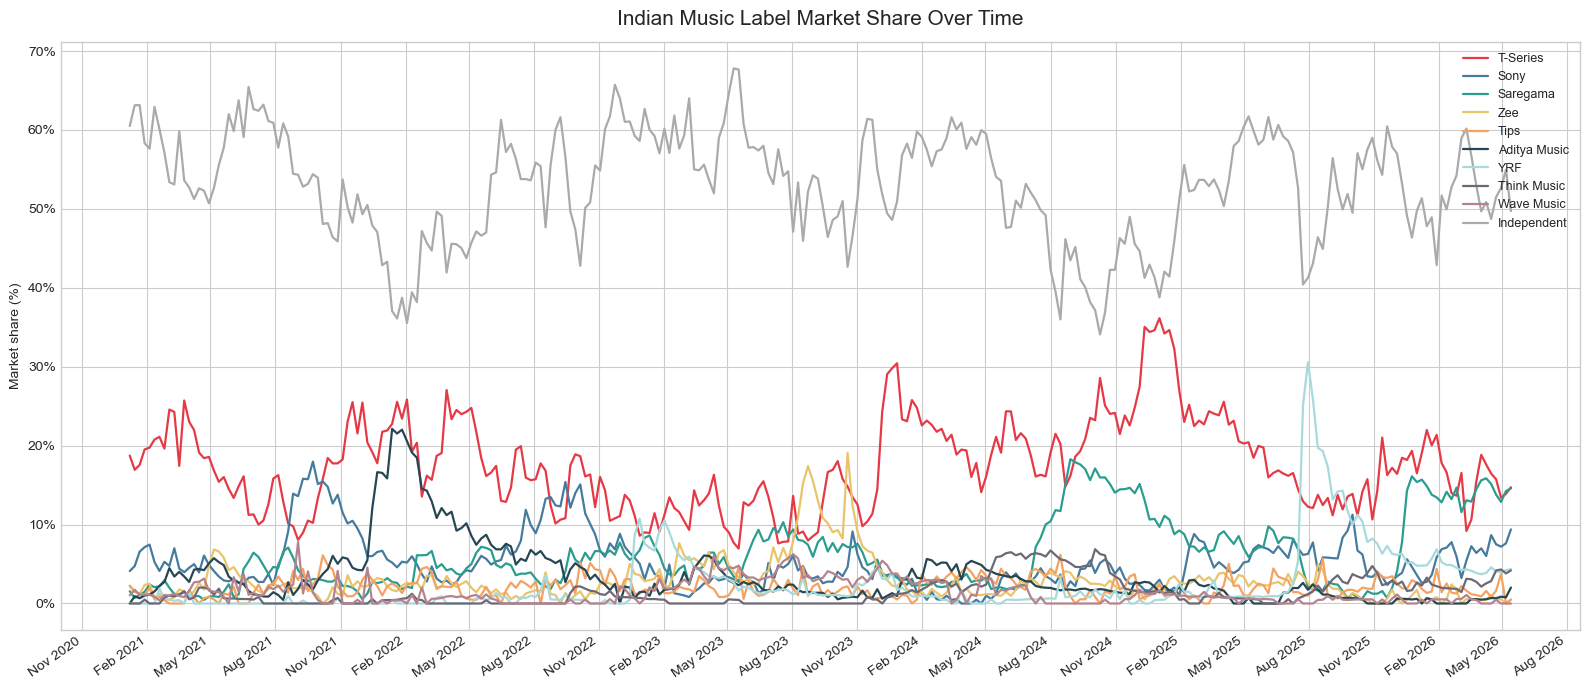

In [ ]:
"""
06_visualization_dashboard.py
==============================
Visualize Indian music label market share trends.

INPUT  : weekly_label_market_share.csv
OUTPUT : charts/  (PNG files)
         market_share_pivot.csv
         hhi_trend.csv
"""

from __future__ import annotations

import logging
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd


# ── Config ────────────────────────────────────────────────────────────────────

INPUT_FILE        = Path("weekly_label_market_share.csv")
INPUT_FILE_NOIND  = Path("weekly_label_market_share_no_indie.csv")
PIVOT_FILE        = Path("market_share_pivot.csv")
PIVOT_FILE_NOIND  = Path("market_share_pivot_no_indie.csv")
HHI_FILE          = Path("hhi_trend.csv")
HHI_FILE_NOIND    = Path("hhi_trend_no_indie.csv")
CHARTS_DIR        = Path("charts")

TOP_LABELS = [
    "T-Series", "Sony", "Saregama", "Zee", "Tips",
    "Aditya Music", "YRF", "Think Music", "Wave Music", "Independent",
]

TOP_LABELS_NOIND = [l for l in TOP_LABELS if l != "Independent"]

# Consistent colour per label — keeps colours stable across every chart
LABEL_COLOURS: dict[str, str] = {
    "T-Series":     "#E63946",
    "Sony":         "#457B9D",
    "Saregama":     "#2A9D8F",
    "Zee":          "#E9C46A",
    "Tips":         "#F4A261",
    "Aditya Music": "#264653",
    "YRF":          "#A8DADC",
    "Think Music":  "#6D6875",
    "Wave Music":   "#B5838D",
    "Independent":  "#AAAAAA",
}

FIGURE_DPI  = 150
STYLE       = "seaborn-v0_8-whitegrid"


# ── Logging ───────────────────────────────────────────────────────────────────

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)


# ── Style ─────────────────────────────────────────────────────────────────────

plt.style.use(STYLE)

CHARTS_DIR.mkdir(parents=True, exist_ok=True)


# ── Helpers ───────────────────────────────────────────────────────────────────

def save(fig: plt.Figure, name: str, suffix: str = "") -> None:
    path = CHARTS_DIR / f"{name}{suffix}.png"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    log.info("Saved chart → %s", path)
    plt.close(fig)


def fmt_xaxis_dates(ax: plt.Axes) -> None:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")


def label_colour(label: str) -> str:
    return LABEL_COLOURS.get(label, "#888888")


# ── Load & clean ──────────────────────────────────────────────────────────────

def load(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Input file not found: {path}")

    log.info("Loading %s", path)
    df = pd.read_csv(path)
    log.info("Raw shape: %s", df.shape)

    df["week"] = pd.to_datetime(df["week"], format="%Y%m%d", errors="coerce")
    bad_dates = df["week"].isna().sum()
    if bad_dates:
        log.warning("Dropping %d rows with unparseable week values", bad_dates)
        df = df.dropna(subset=["week"])

    return df


# ── Chart functions ───────────────────────────────────────────────────────────

def chart_line_trend(pivot: pd.DataFrame, suffix: str = "") -> None:
    """Line chart: weekly market share per label."""
    fig, ax = plt.subplots(figsize=(16, 7))

    for label in pivot.columns:
        ax.plot(
            pivot.index, pivot[label],
            label=label, color=label_colour(label), linewidth=1.6,
        )

    ax.set_title("Indian Music Label Market Share Over Time", fontsize=15, pad=12)
    ax.set_ylabel("Market share (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    fmt_xaxis_dates(ax)
    ax.legend(loc="upper right", fontsize=9, framealpha=0.8)
    fig.tight_layout()
    save(fig, "01_market_share_line_trend", suffix)


def chart_stacked_area(pivot: pd.DataFrame, suffix: str = "") -> None:
    """Stacked area chart: attention share over time."""
    fig, ax = plt.subplots(figsize=(16, 7))

    colours = [label_colour(c) for c in pivot.columns]
    ax.stackplot(
        pivot.index, pivot.T,
        labels=pivot.columns, colors=colours, alpha=0.85,
    )

    ax.set_title("Indian Music Industry Attention Share", fontsize=15, pad=12)
    ax.set_ylabel("Market share (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    fmt_xaxis_dates(ax)
    ax.legend(loc="upper left", fontsize=9, framealpha=0.8)
    fig.tight_layout()
    save(fig, "02_attention_share_stacked_area", suffix)


def chart_latest_week_bar(df: pd.DataFrame, suffix: str = "") -> None:
    """Bar chart: market share snapshot for the most recent week."""
    latest_week = df["week"].max()
    latest = (
        df[df["week"] == latest_week]
        .sort_values("market_share_pct", ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(13, 6))
    bars = ax.bar(
        latest["label"], latest["market_share_pct"],
        color=[label_colour(l) for l in latest["label"]],
        edgecolor="white", linewidth=0.5,
    )

    # Value labels on bars
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.3,
            f"{h:.1f}%", ha="center", va="bottom", fontsize=8,
        )

    ax.set_title(
        f"Latest Weekly Market Share — {latest_week.strftime('%d %b %Y')}",
        fontsize=15, pad=12,
    )
    ax.set_ylabel("Market share (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
    fig.tight_layout()
    save(fig, "03_latest_week_bar", suffix)


def chart_overall_bar(df: pd.DataFrame, suffix: str = "") -> None:
    """Bar chart: cumulative market share across the full dataset."""
    overall = (
        df.groupby("label")["label_views"].sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    overall["pct"] = (overall["label_views"] / overall["label_views"].sum() * 100).round(2)
    overall = overall.head(15)

    fig, ax = plt.subplots(figsize=(13, 6))
    bars = ax.bar(
        overall["label"], overall["pct"],
        color=[label_colour(l) for l in overall["label"]],
        edgecolor="white", linewidth=0.5,
    )

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.3,
            f"{h:.1f}%", ha="center", va="bottom", fontsize=8,
        )

    ax.set_title("Overall Indian Music Market Share", fontsize=15, pad=12)
    ax.set_ylabel("Market share (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
    fig.tight_layout()
    save(fig, "04_overall_market_share_bar", suffix)


def chart_hhi(hhi: pd.DataFrame, suffix: str = "") -> None:
    """Line chart: Herfindahl–Hirschman Index over time."""
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(hhi["week"], hhi["HHI"], color="#E63946", linewidth=1.6)
    ax.fill_between(hhi["week"], hhi["HHI"], alpha=0.12, color="#E63946")

    # Threshold reference lines
    for threshold, label in [(0.15, "Moderate (0.15)"), (0.25, "Concentrated (0.25)")]:
        ax.axhline(threshold, linestyle="--", linewidth=0.8, color="#888", alpha=0.7)
        ax.text(hhi["week"].iloc[-1], threshold + 0.003, label, fontsize=8, color="#555")

    ax.set_title("Indian Music Market Concentration (HHI)", fontsize=15, pad=12)
    ax.set_ylabel("HHI")
    fmt_xaxis_dates(ax)
    fig.tight_layout()
    save(fig, "05_hhi_trend", suffix)


# ── Computations ──────────────────────────────────────────────────────────────

def build_pivot(df: pd.DataFrame, top_labels: list[str] = TOP_LABELS) -> pd.DataFrame:
    df_top = df[df["label"].isin(top_labels)]
    pivot = df_top.pivot_table(
        index="week", columns="label",
        values="market_share_pct", aggfunc="sum",
    ).fillna(0)
    ordered = [l for l in top_labels if l in pivot.columns]
    return pivot[ordered]


def compute_hhi(df: pd.DataFrame) -> pd.DataFrame:
    hhi = (
        df.groupby(["week", "label"])["market_share"]
        .sum()
        .groupby("week")
        .apply(lambda x: (x ** 2).sum())
        .rename("HHI")
        .reset_index()
    )
    return hhi


def generate_charts(
    df: pd.DataFrame,
    top_labels: list[str],
    pivot_file: Path,
    hhi_file: Path,
    suffix: str,
) -> None:
    """Build and save all charts for a given dataset."""
    pivot = build_pivot(df, top_labels=top_labels)
    pivot.to_csv(pivot_file)
    log.info("Saved → %s", pivot_file)

    hhi = compute_hhi(df)
    hhi.to_csv(hhi_file, index=False)
    log.info("Saved → %s", hhi_file)

    chart_line_trend(pivot, suffix)
    chart_stacked_area(pivot, suffix)
    chart_latest_week_bar(df, suffix)
    chart_overall_bar(df, suffix)
    chart_hhi(hhi, suffix)


# ── Main ──────────────────────────────────────────────────────────────────────

def main() -> None:
    # ── Full market (with Independent) ────────────────────────────────────────
    log.info("── Full market ──────────────────────────────────────────────────")
    df = load(INPUT_FILE)
    generate_charts(df, TOP_LABELS, PIVOT_FILE, HHI_FILE, suffix="")

    # ── Labelled market (Independent excluded) ────────────────────────────────
    if INPUT_FILE_NOIND.exists():
        log.info("── No-indie market ──────────────────────────────────────────────")
        df_noind = load(INPUT_FILE_NOIND)
        generate_charts(
            df_noind, TOP_LABELS_NOIND,
            PIVOT_FILE_NOIND, HHI_FILE_NOIND,
            suffix="_no_indie",
        )
    else:
        log.warning("%s not found — skipping no-indie charts", INPUT_FILE_NOIND)

    log.info("All charts saved to %s/", CHARTS_DIR)


if __name__ == "__main__":
    main()